![Helmholtz AI logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Experimental Attention-aware LRP for DistilBERT

This tutorial explains one DistilBERT emotion prediction with [LXT](https://github.com/rachtibat/LRP-eXplains-Transformers), an attention-aware LRP implementation. It uses a labelled example from the public [Emotion dataset](https://huggingface.co/datasets/dair-ai/emotion).

**Model:** `pngwn/distilbert-emotion`  
**Task:** six-class emotion classification

## Learning objectives

By the end of this notebook, you will be able to:

1. load a labelled emotion example and a pretrained DistilBERT classifier;
2. explain why token IDs must be converted to embeddings before attribution;
3. patch DistilBERT's attention and MLP operations for LXT's Input×Gradient AttnLRP workflow; and
4. check whether an explanation is numerically stable and changes the model score when an important token is masked.

> **Experimental status:** LXT officially supports BERT, but not DistilBERT. This notebook provides a small compatibility patch for Transformers 4.52.4. A successful run is a prototype result, not proof of official DistilBERT support.

## 1. Getting started

### Before you begin

LXT is tested against a specific PyTorch and Transformers stack. Create the separate environment from the repository root, then select it as this notebook's kernel:

```bash
conda create -n xai-attnlrp python=3.11
conda activate xai-attnlrp
pip install -r requirements_lxt_attnlrp.txt
```

The first run downloads the public dataset and pretrained checkpoint from Hugging Face.

### Step 1.1 — Import libraries

We run on CPU first. That makes this compatibility prototype easier to reproduce and avoids mixing an LRP-rule issue with accelerator-specific numerical behaviour.

In [1]:
from pathlib import Path
import sys

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

project_root = Path.cwd()
if not (project_root / "notebooks").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "notebooks"))

from lxt_distilbert_patch import patch_distilbert_for_attnlrp

DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

/Users/haider/miniconda3/envs/xai-attnlrp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 2. Load a public labelled example

### Step 2.1 — Inspect the Emotion dataset

[`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion) contains short English texts labelled with one of six emotions: sadness, joy, love, anger, fear, or surprise.

We use a fixed test example so that readers can reproduce the same result. The dataset label is the expected answer; the model prediction may still differ.

In [2]:
EMOTION_DATASET = "dair-ai/emotion"
SAMPLE_INDEX = 0

emotion = load_dataset(EMOTION_DATASET, "split")
label_names = emotion["test"].features["label"].names
example = emotion["test"][SAMPLE_INDEX]
text = example["text"]
expected_label = label_names[example["label"]]

print(f"Available labels: {label_names}")
print(f"Text: {text}")
print(f"Dataset label: {expected_label}")

Available labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Text: im feeling rather rotten so im not very ambitious right now
Dataset label: sadness


## 3. Load the emotion classifier

### Step 3.1 — Choose a model trained for the same labels

`pngwn/distilbert-emotion` is a DistilBERT checkpoint fine-tuned on this dataset. Its model card documents the label order used below.

### Step 3.2 — Use eager attention

The compatibility patch replaces the explicit attention operations. Passing `attn_implementation="eager"` prevents Transformers from switching to an optimised attention kernel that hides those operations.

In [3]:
MODEL_NAME = "pngwn/distilbert-emotion"
MODEL_LABELS = ["sadness", "joy", "love", "anger", "fear", "surprise"]

if MODEL_LABELS != label_names:
    raise ValueError("The checkpoint's documented labels do not match the dataset labels.")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager",
).to(DEVICE)
model.eval()

encoded = tokenizer(text, return_tensors="pt")
model_inputs = {
    name: tensor.to(DEVICE)
    for name, tensor in encoded.items()
    if name in {"input_ids", "attention_mask"}
}

with torch.no_grad():
    original_logits = model(**model_inputs).logits
    target_idx = original_logits.argmax(dim=-1).item()
    confidence = original_logits.softmax(dim=-1)[0, target_idx].item()

print(f"Prediction: {MODEL_LABELS[target_idx]}")
print(f"Confidence: {confidence:.3f}")

Prediction: sadness
Confidence: 0.995


## 4. Prepare DistilBERT for attention-aware LRP

### Step 4.1 — Why patch the model?

Normal gradients describe how the output changes after a tiny change to an input. AttnLRP changes the *backward* calculation so attention, normalization, and activations split the model score according to LRP rules.

The local helper patches four DistilBERT components: attention matrix multiplications, GELU in the feed-forward block, LayerNorm, and dropout. It does not change the model's forward prediction.

### Step 4.2 — Verify the forward pass is unchanged

Before trusting an explanation, compare logits before and after patching. A meaningful difference would show that the patch accidentally changed the classifier itself.

In [4]:
patch_distilbert_for_attnlrp(verbose=True)

with torch.no_grad():
    patched_logits = model(**model_inputs).logits

max_logit_difference = (original_logits - patched_logits).abs().max().item()
print(f"Largest logit difference after patching: {max_logit_difference:.2e}")

if max_logit_difference > 1e-5:
    raise RuntimeError("The patch changed the forward prediction; stop before attributing.")

Patched LayerNorm
Patched Dropout
Patched MultiHeadSelfAttention
Patched FFN
Largest logit difference after patching: 2.38e-07


## 5. Compute token relevance

### Step 5.1 — Attribute embeddings, not token IDs

Token IDs are labels such as `1045`; they cannot receive gradients. We instead pass the word-embedding vectors to the model and ask PyTorch for their gradients.

### Step 5.2 — Explain one class logit

We backpropagate from the predicted emotion's raw score. LXT's patched backward pass makes `embedding × gradient` the token relevance value for this prototype.

In [5]:
input_ids = model_inputs["input_ids"]
attention_mask = model_inputs["attention_mask"]
word_embeddings = model.distilbert.embeddings.word_embeddings(input_ids)
word_embeddings = word_embeddings.detach().requires_grad_(True)

model.zero_grad(set_to_none=True)
outputs = model(inputs_embeds=word_embeddings, attention_mask=attention_mask)
target_logit = outputs.logits[0, target_idx]
target_logit.backward()

token_relevance = (word_embeddings * word_embeddings.grad).sum(dim=-1).squeeze(0)
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

## 6. Check the explanation before visualising it

A heatmap is useful only after basic checks pass:

1. the patch leaves forward logits unchanged;
2. all relevance values are finite; and
3. masking a highly relevant token has a measurable effect on the explained score.

The relevance sum will not necessarily equal the full logit here: this notebook attributes **word embeddings only**, while positional embeddings and model biases remain fixed. We print the difference as a diagnostic rather than pretending it is a pass/fail conservation test.

In [6]:
is_finite = torch.isfinite(token_relevance).all().item()
relevance_sum = token_relevance.sum().item()
word_only_gap = target_logit.item() - relevance_sum

print(f"All relevance values are finite: {is_finite}")
print(f"Target logit: {target_logit.item():+.4f}")
print(f"Sum of word relevance: {relevance_sum:+.4f}")
print(f"Word-only gap: {word_only_gap:+.4f}")

if not is_finite:
    raise RuntimeError("Non-finite relevance values; do not interpret this explanation.")

All relevance values are finite: True
Target logit: +5.5142
Sum of word relevance: +4.4885
Word-only gap: +1.0257


## 7. Inspect and visualise token relevance

The next helper normalises scores only for this sentence. Green supports the predicted emotion; red opposes it. A darker colour means a larger relative score.

Special tokens (`[CLS]`, `[SEP]`) are model bookkeeping tokens, not words a person wrote. They are shown for transparency but excluded when we choose a token for the masking check.

         [CLS]  -0.019
            im  +0.050
       feeling  +0.967
        rather  +0.029
        rotten  +1.000
            so  -0.003
            im  +0.022
           not  -0.000
          very  -0.006
     ambitious  -0.257
         right  +0.015
           now  +0.015
         [SEP]  -0.548


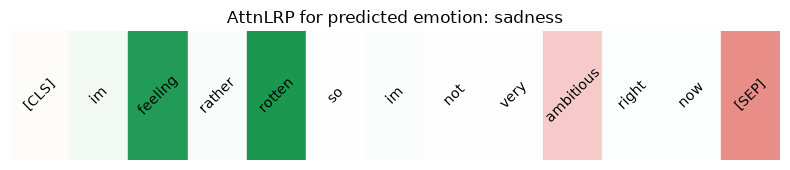

In [7]:
def normalise(scores):
    scale = scores.abs().max()
    return scores if scale == 0 else scores / scale


def plot_token_heatmap(tokens, scores, title):
    scores = scores.detach().cpu().numpy()
    colours = mcolors.LinearSegmentedColormap.from_list(
        "relevance", ["#d73027", "#ffffff", "#1a9850"]
    )
    norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    fig, ax = plt.subplots(figsize=(max(8, len(tokens) * 0.6), 1.8))
    for index, (token, score) in enumerate(zip(tokens, scores)):
        ax.add_patch(plt.Rectangle((index, 0), 1, 1, color=colours(norm(score))))
        ax.text(index + 0.5, 0.5, token, ha="center", va="center", rotation=45)

    ax.set(xlim=(0, len(tokens)), ylim=(0, 1), title=title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


normalised_relevance = normalise(token_relevance)
for token, score in zip(tokens, normalised_relevance.detach().cpu().tolist()):
    print(f"{token:>14}  {score:+.3f}")

plot_token_heatmap(
    tokens,
    normalised_relevance,
    title=f"AttnLRP for predicted emotion: {MODEL_LABELS[target_idx]}",
)

## 8. Run a simple masking check

Choose the content token with the largest **positive** relevance, replace it with `[MASK]`, and recompute the same emotion logit.

If the score falls, the token passed a basic sanity check: changing the token made the model less confident in the explained emotion. This is not a proof of causality—masking can create an unnatural sentence—but it is more informative than looking at colours alone.

In [8]:
special_ids = set(tokenizer.all_special_ids)
content_positions = [
    index for index, token_id in enumerate(input_ids[0].tolist()) if token_id not in special_ids
]
positive_positions = [
    index for index in content_positions if token_relevance[index] > 0
]

if not positive_positions:
    raise RuntimeError("No content token has positive relevance for the predicted class.")

top_position = max(positive_positions, key=lambda index: token_relevance[index].item())
masked_ids = input_ids.clone()
masked_ids[0, top_position] = tokenizer.mask_token_id

with torch.no_grad():
    masked_logit = model(input_ids=masked_ids, attention_mask=attention_mask).logits[0, target_idx]

logit_drop = target_logit.item() - masked_logit.item()
print(f"Masked token: {tokens[top_position]!r}")
print(f"Original {MODEL_LABELS[target_idx]} logit: {target_logit.item():+.4f}")
print(f"Masked-token logit: {masked_logit.item():+.4f}")
print(f"Logit drop: {logit_drop:+.4f}")
print(f"Sanity check passed (score fell): {logit_drop > 0}")

Masked token: 'rotten'
Original sadness logit: +5.5142
Masked-token logit: -0.8433
Logit drop: +6.3575
Sanity check passed (score fell): True


## Draft-only: sanity checks across emotion examples

> **Remove this section before publishing the final tutorial.** It is included while validating the experimental DistilBERT patch.

The following test selects one held-out example for each emotion. For every example it:

1. computes token relevance for the predicted class;
2. checks that all scores are finite; and
3. masks the content token with the highest positive relevance, then measures whether the predicted-class logit falls.

A failed masking check does not automatically prove the explanation is wrong: replacing a word with `[MASK]` creates an artificial sentence. It is still a useful warning when a supposedly supportive token makes the score rise after being removed.

In [9]:
def explain_example(text):
    encoded = tokenizer(text, return_tensors="pt", truncation=True)
    inputs = {
        name: tensor.to(DEVICE)
        for name, tensor in encoded.items()
        if name in {"input_ids", "attention_mask"}
    }
    embeddings = model.distilbert.embeddings.word_embeddings(inputs["input_ids"])
    embeddings = embeddings.detach().requires_grad_(True)

    model.zero_grad(set_to_none=True)
    outputs = model(inputs_embeds=embeddings, attention_mask=inputs["attention_mask"])
    predicted_index = outputs.logits.argmax(dim=-1).item()
    logit = outputs.logits[0, predicted_index]
    logit.backward()

    relevance = (embeddings * embeddings.grad).sum(dim=-1).squeeze(0)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    content_positions = [
        index
        for index, token_id in enumerate(inputs["input_ids"][0].tolist())
        if token_id not in tokenizer.all_special_ids and relevance[index] > 0
    ]
    if not content_positions:
        return {
            "prediction": MODEL_LABELS[predicted_index],
            "finite": torch.isfinite(relevance).all().item(),
            "masked_token": None,
            "logit_drop": None,
        }

    top_position = max(content_positions, key=lambda index: relevance[index].item())
    masked_ids = inputs["input_ids"].clone()
    masked_ids[0, top_position] = tokenizer.mask_token_id
    with torch.no_grad():
        masked_logit = model(
            input_ids=masked_ids,
            attention_mask=inputs["attention_mask"],
        ).logits[0, predicted_index]

    return {
        "prediction": MODEL_LABELS[predicted_index],
        "finite": torch.isfinite(relevance).all().item(),
        "masked_token": tokens[top_position],
        "logit_drop": logit.item() - masked_logit.item(),
    }


sample_by_label = {}
for index, item in enumerate(emotion["test"]):
    sample_by_label.setdefault(item["label"], index)
    if len(sample_by_label) == len(label_names):
        break

results = []
for label_index, index in sorted(sample_by_label.items()):
    item = emotion["test"][index]
    result = explain_example(item["text"])
    result["dataset_label"] = label_names[label_index]
    results.append(result)

for result in results:
    drop = result["logit_drop"]
    check = "n/a" if drop is None else str(drop > 0)
    print(
        f"{result['dataset_label']:>8} → {result['prediction']:<8} | "
        f"finite: {result['finite']!s:<5} | "
        f"masked: {str(result['masked_token']):<12} | "
        f"score fell: {check}"
    )

finite_count = sum(result["finite"] for result in results)
mask_checks = [result["logit_drop"] > 0 for result in results if result["logit_drop"] is not None]
print(f"\nFinite relevance: {finite_count}/{len(results)} examples")
print(f"Masking lowered the score: {sum(mask_checks)}/{len(mask_checks)} applicable examples")

 sadness → sadness  | finite: True  | masked: rotten       | score fell: True
     joy → joy      | finite: True  | masked: optimistic   | score fell: True
    love → love     | finite: True  | masked: supportive   | score fell: True
   anger → anger    | finite: True  | masked: anger        | score fell: True
    fear → fear     | finite: True  | masked: uncomfortable | score fell: True
surprise → surprise | finite: True  | masked: stunned      | score fell: True

Finite relevance: 6/6 examples
Masking lowered the score: 6/6 applicable examples


## 9. Interpret the result

Use all three pieces of evidence together:

- Does the prediction match the dataset label?
- Are the highlighted words plausible in the sentence?
- Did masking the highest positive-relevance content token lower the explained logit?

A positive answer to the last question supports this explanation for this one input. A negative answer means the heatmap needs more investigation before it is used as evidence.

### Exercise

Change `SAMPLE_INDEX`, rerun from Section 2, and compare an example where the classifier is correct with one where it is wrong. Do the most relevant tokens and the masking check tell a coherent story?

## 10. Limitations and next steps

- This is an **experimental DistilBERT patch**. LXT's documented BERT support does not automatically guarantee support for every BERT-derived architecture.
- The relevance scores explain the model's behaviour, not whether the model is correct or fair.
- This notebook attributes word embeddings while holding positional embeddings and model biases fixed. The printed word-only gap reflects that choice.
- Token masking is only one sanity check. For a stronger evaluation, test several examples and compare deletion curves against another method.

### References

- [LXT / AttnLRP documentation](https://lxt.readthedocs.io/en/latest/)
- Achtibat et al., [*AttnLRP: Attention-Aware Layer-Wise Relevance Propagation for Transformers*](https://arxiv.org/abs/2402.05602) (2024)
- [Emotion dataset card](https://huggingface.co/datasets/dair-ai/emotion)
- [Emotion classifier model card](https://huggingface.co/pngwn/distilbert-emotion)